In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import Modules.EnergyMass as eg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

In [4]:
cplot.general()

### Background solutions

In [5]:
tesGalo = np.array([
[0.9096109671440298, 1.4608342918684363, 0.0, 25, [0.99, 0.025, 0.0], [0, 1, 0], 0],
[0.8352695591049114, 1.34108243150, 0.0, 25, [0.9, 0.15, 0], [0, 1, 0], 0]
], dtype=object)

In [6]:
u0val = tesGalo[:, :2]
s0val = tesGalo[:, 4]
rmaxval = tesGalo[:, 3]

In [7]:
len(u0val)

2

Finding a profile with nx, ny, nz [0 1 0] nodes
Found: U0x =  0.9096109671440298  U0y =  1.4608342918684363  U0z =  0.0 radio 22


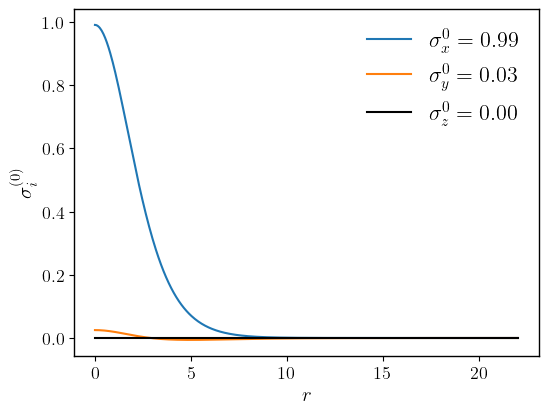

Finding a profile with nx, ny, nz [0 1 0] nodes
Found: U0x =  0.8352695591049115  U0y =  1.3410824315  U0z =  0.0 radio 22


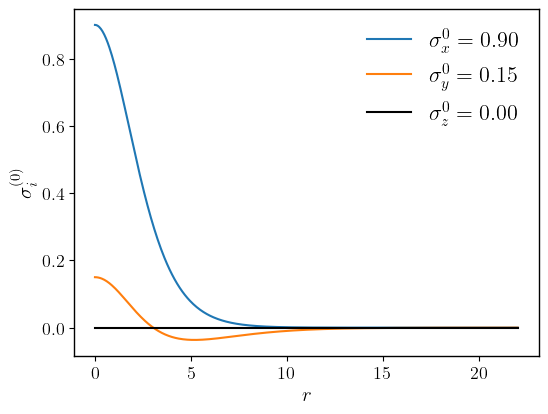

In [8]:
LambT = 0 # autointeracción: 1 (repulsive), 0 (without selinteraction), -1 (attractive)

nx, ny, nz = 0, 1, 0  # node numbers: nx -> nodes of \sigma_x, ny  -> nodes of \sigma_y, ...
nodos = [nx, ny, nz]  # list of node info

p1x = 0  # the first derivative value (p1x), the latter is zero
p1y = 0  # The same in y-axes
p1z = 0  # The same in z-axes
u1x, u1y, u1z = 0, 0, 0  # The first derivatives of the x, y, and z effective potential components are all zero.

# Range of values used as seed for the effective potential
Uzint = [0, 0]

met = 'DOP853'
gamma = 0 # 1 radial
Rtol = 1e-13
Atol = 1e-15

delt = 0.5
datos = []
for i in range(len(u0val)):  # The central amplitude of \sigma_x (p0x) and len(s0val)
    p0x, p0y, p0z = s0val[i]
    ux, uy = u0val[i]
    Uxint = [ux-delt, ux+delt]
    Uyint = [uy-delt, uy+delt]
    
    Uintrs = [Uxint, Uyint, Uzint]
    numFields = len(Uintrs)
    rmax = rmaxval[i] - 3  # iteration radius
    
    Ini0 = [p0x, p1x, p0y, p1y, p0z, p1z, u1x, u1y, u1z]  # boundary conditions list
    #u0Val, rTmax, events = bg.MultFreq_solveG2(Ini0, numFields=numFields, Uintrs=Uintrs, rmax=rmax, LambT=LambT, gamma=gamma, met=met,
    #                                            nodos=nodos, lim=1e-20, info=False, klim=5000, outval=0, delta=0.2, Rtol=Rtol, Atol=Atol)  # part=[0,0] para componente y sola

    u0Val, rTmax, events = bg.MultFreq_solveG2_vO(Ini0, Uintrs, rmax=rmax, LambT=LambT, rmin=0, nodos=nodos, 
                      met=met,Rtol=Rtol, Atol=Atol, lim=1e-20, info=False, klim=5000, outval=13, delta=0.2)

    # plot the result
    U0 = np.zeros(4*numFields)
    U0[:2*numFields] = Ini0[:2*numFields]
    U0[2*numFields+1::2] = Ini0[2*numFields:]
    U0[2*numFields::2] = u0Val
    arg = [numFields, LambT, gamma]

    cplot.plotPerf(U0, rTmax, arg=arg, px=True, py=True, lim=False)
    
    #[U0x, U0y, U0z, rTmax, [p0x, p0y, p0z], nodos, LambT]
    datos.append([u0Val[0], u0Val[1], u0Val[2], rTmax, [p0x, p0y, p0z], nodos, LambT])

In [22]:
# datos

In [10]:
# Improving the previous results
confidata, confidataU0 = [], []
for datinf in datos:
    U0x, U0y, U0z, rTmax, [p0x, p0y, p0z], nodos, LambT = datinf

    rext = 5 # increasing the rTmax iteration radius
    rmin, rmax = 0, rTmax + rext
    limit = [rmin, rmax]

    p1x, p1y, p1z, u1x, u1y, u1z = 0, 0, 0, 0, 0, 0  # first derivatives

    uk = [U0x, U0y, U0z]  #  seeds

    # solving
    V0X = [p0x, p1x, p0y, p1y, p0z, p1z, None, u1x, None, u1y, None, u1z]
    V0Duk = np.zeros(12*3)
    V0Duk[6] = 1
    V0Duk[20] = 1
    V0Duk[-2] = 1
    V0 = np.concatenate((V0X, V0Duk))

    # Boolenos
    indck = np.concatenate(([False, False, False, False, False, False, True, False, True, False, True, False], [False]*36))
    V0[indck] = uk

    BCind = [0, 0, 0]

    indXc = np.array([False]*48)
    indXc[:5:2] = True 

    inddXc = np.array([False]*48)
    inddXc[12::12] =  True
    inddXc[14::12] =  True
    inddXc[16::12] =  True

    arg = [LambT]

    met = 'DOP853'
    Rtol = 1e-12 # 1e-13
    Atol = 1e-14 # 1e-14

    V0fit = bg.fitting(bg.systemMultFreqTot, V0, indck, indXc, BCind, inddXc, limit, argf=arg, tol=1e-18, met=met, Rtol=Rtol, Atol=Atol)
    
    U0 = V0fit[:12]
    U0x, U0y, U0z = U0[6], U0[8], U0[10]
    confidata.append([U0x, U0y, U0z, rmax, [p0x, p0y, p0z], nodos, LambT])
    confidataU0.append(U0)

Stop [9.88646678e-09 2.31068980e-14 0.00000000e+00] k 500 ck [0.90961097 1.46083428 0.        ]
Stop [2.96085357e-10 3.64698330e-14 0.00000000e+00] k 500 ck [0.83526956 1.34108244 0.        ]


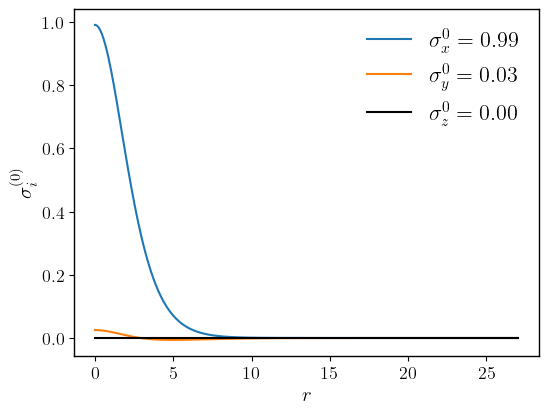

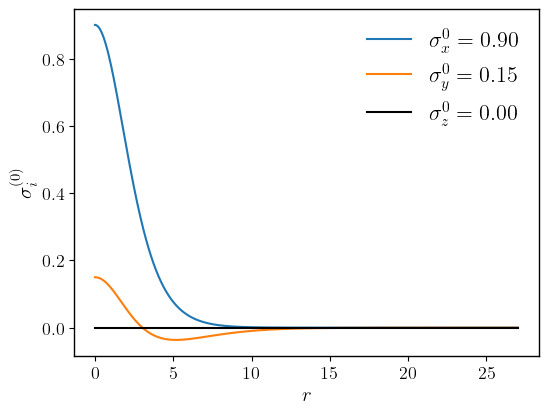

In [11]:
# plot
arg = [LambT]
for U0i in confidataU0:
   cplot.plotPerf(U0i, rmax, arg=arg, met=met, Rtol=Rtol, Atol=Atol, px=True, py=True, lim=False)

Mass values: [3.4551675621894042, 3.4551675621894042, 3.4551675621894042]
Eigenvalues of energy: [-0.9699027406155263, -0.41867942301139016, -1.879513707760199]
26.91901345950673


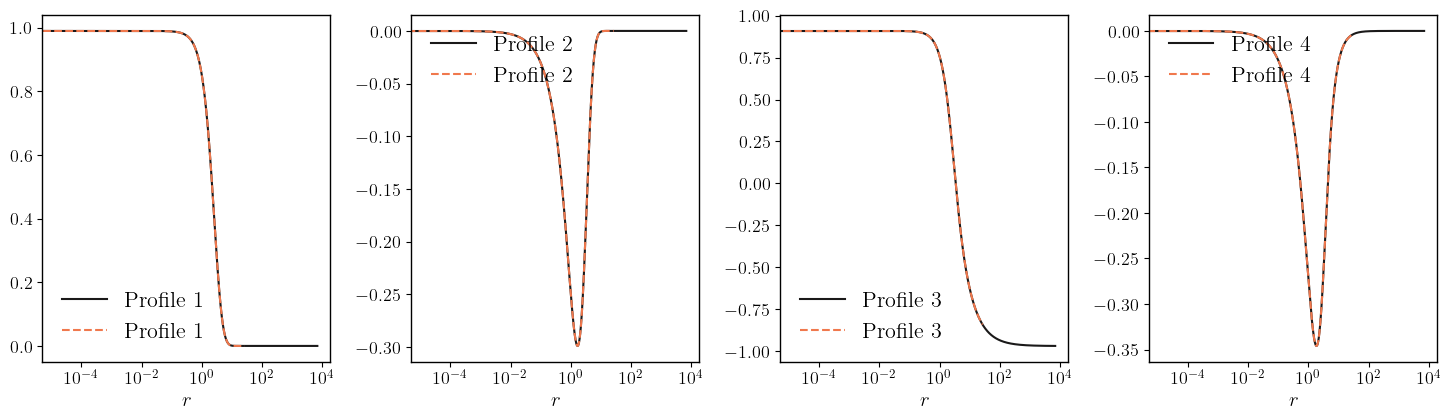

26.91901345950673


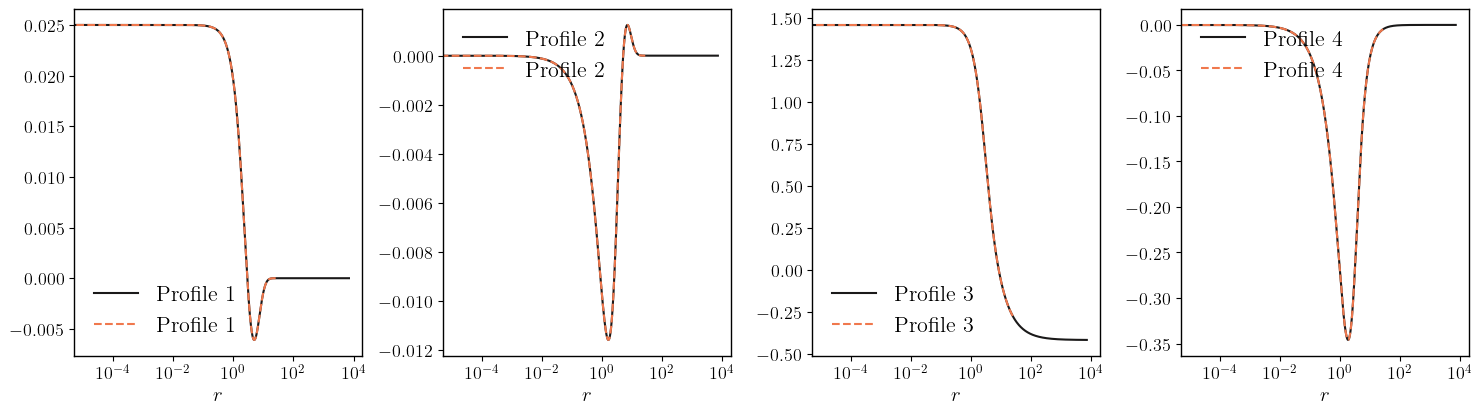

Mass values: [3.462428501057023, 3.462428501057023, 3.462428501057023]
Eigenvalues of energy: [-0.909388000076869, -0.40357512098987014, -1.7446575591557496]
26.91901345950673


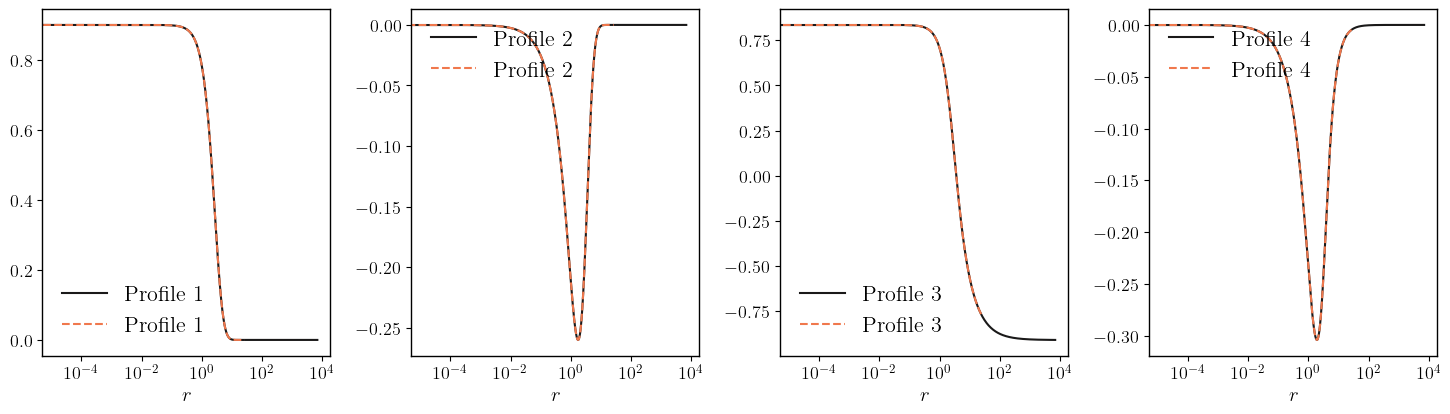

26.91901345950673


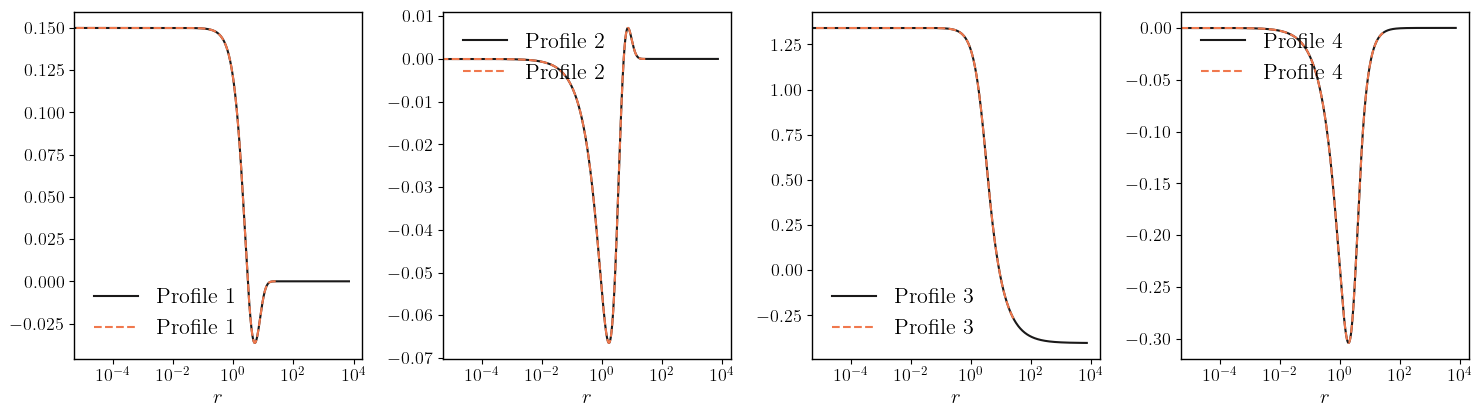

In [12]:
# Extendiendo los perfiles
Ext = 7000
Np = int(2e06)

#met = 'DOP853'
#Rtol = 1e-10
#Atol = 1e-12

confidataEx = []
for confi in confidata: # confidata datos
    dataEx = bg.mainExt(confi, mult=True, rmin=0, Nptos=Np, met=met, metExp=1, info=True, indF=-6000,
                    Rtol=Rtol, Atol=Atol, deltaExt=Ext, yscale='linear', xscale='log')  # out [[Ei, rDnew, sDnew, dsDnew, uDnew, duDnew], ..]
    confidataEx.append(dataEx)

In [13]:
# Making a null data
zerof = lambda r: 0.*r
rd = confidataEx[0][0][1]
data0 = [0., rd, zerof(rd), zerof(rd), zerof(rd), zerof(rd)]

In [14]:
# Adding a null solution

for i in range(len(confidataEx)):
    # confidataEx[i].insert(0, data0). # usar cuando la zero esta en la component x
    confidataEx[i].append(data0)  # usar cuando el zero está en la componente z
    # confidataEx[0].append(data0)  # usar consecutivo del de arriba cuando tienes cero en y, z

(0.0, 150.0)

/Users/armandoroqueestrada/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/armandoroqueestrada/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


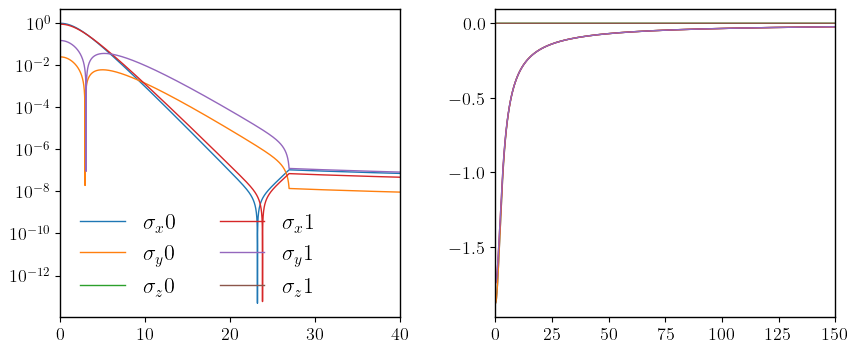

In [18]:
# Graficando de nuevo
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.28))
label = ['x', 'y', 'z']
for i in range(len(confidataEx)):
    for ind, data in enumerate(confidataEx[i]):
        Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = data
        #ax[0].plot(rDnew, np.abs(sDnew), label=r'$\sigma_%s$'%label[ind], lw=1)
        ax[0].plot(rDnew, abs(sDnew), label=r'$\sigma_%s%s$'%(label[ind], i), lw=1)
        ax[1].plot(rDnew, Ei - uDnew, label=r'$u_%s%s$'%(label[ind], i), lw=1)

ax[0].legend(frameon=False, ncols=2)
ax[0].set_xlim(0, 40)
ax[0].set_yscale('log')

ax[1].set_xlim(0, 150)

In [19]:
# saving
for i in range(len(confidataEx)):
    temp = np.array(confidataEx[i], dtype="object")
    np.save("sigma_0_Mult_Galo_%s"%i, temp)

## Cargando perfiles

In [20]:
datasS0 = [np.load("sigma_0_Mult_Galo_%s.npy"%i, allow_pickle=True) for i in range(2)]

(0.0, 50.0)

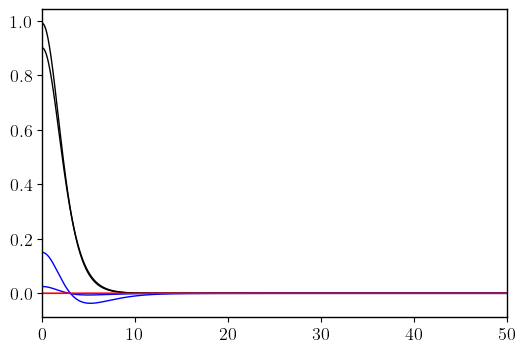

In [21]:
# Test scaling
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.28))
color = ['k', 'b', 'r']
label = ['x', 'y', 'z']
for s0 in datasS0:
    for ind, data in enumerate(s0):
        Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = data
        ax.plot(rDnew, sDnew, label=r'$\sigma_%s$'%label[ind], c=color[ind], lw=1)
# ax.legend(frameon=False)
ax.set_xlim(0, 50)